# Lecture 10 Tutorial: Linear Discrete Kalman Filter vs. Least Squares Estimator

## 1. Learning Objectives
In this tutorial, we will:
1.  Simulate a **2D dynamic system** (Constant Velocity model).
2.  Implement a **Discrete Kalman Filter (KF)** (4D State: Position + Velocity).
3.  Implement a **Snapshot Least Squares Estimator (LSE)** (2D State: Position Only).
    *   We use the **Least Squares Equation** explicitly: $\hat{x} = (H^T R^{-1} H)^{-1} H^T R^{-1} z$.
    *   We demonstrate that for a single snapshot, we must restrict estimation to Position only ($H=I$).
4.  Contrast performance: KF smooths using dynamics; LSE blindly follows measurements.

## 2. Estimator Formulation

### Kalman Filter (KF)
System Model ($x_k = [p_x, v_x, p_y, v_y]^T$):
$$
x_{k+1} = \Phi x_k + w_k, \quad \Phi = \begin{bmatrix} 1 & dt & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & dt \\ 0 & 0 & 0 & 1 \end{bmatrix}
$$
#### Process Noise Derivation
We derive the discrete process noise $w_k$ and its covariance $Q$ from the continuous-time dynamics. 
The full 4D continuous state is $x(t) = [p_x, v_x, p_y, v_y]^T$. The random acceleration input is $a(t) = [a_x(t), a_y(t)]^T$.
The continuous dynamics are:
$$
\dot{x}(t) = A x(t) + B_{cont} a(t), \quad 
A = \begin{bmatrix} 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 0 & 0 \end{bmatrix}, \quad 
B_{cont} = \begin{bmatrix} 0 & 0 \\ 1 & 0 \\ 0 & 0 \\ 0 & 1 \end{bmatrix}
$$
Assuming piecewise constant acceleration over $\Delta t$, the discrete input matrix $\Gamma$ ($4 \times 2$) is:
$$
\Gamma = \int_{0}^{\Delta t} e^{A(\Delta t - \tau)} B_{cont} d\tau = \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0 \\ \Delta t & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ 0 & \Delta t \end{bmatrix}
$$
The discrete process noise vector is $w_k = \Gamma a_k$, where $w_k \in \mathbb{R}^4$.
The covariance matrix $Q$ ($4 \times 4$) is:
$$
Q = E[w_k w_k^T] = \Gamma E[a_k a_k^T] \Gamma^T = \sigma_a^2 \Gamma \Gamma^T
$$
Reference: **Lecture 9, Section 5 (Discrete-Time Stochastic Systems)**.

Measurement Model ($z_k = [p_x, p_y]^T$):
$$
z_k = H_{KF} x_k + v_k, \quad H_{KF} = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 \end{bmatrix}
$$
Where $w_k \sim N(0, Q)$ and $v_k \sim N(0, R)$.

### Snapshot Least Squares (LSE)
We apply the **Least Squares Equation** on the current snapshot $z_k$.

#### Why Position Only? (The Singularity Issue)
If we attempted to estimate the full 4D state $x_{4D} = [p_x, v_x, p_y, v_y]^T$ from a single snapshot $z_k$, our measurement matrix would be:
$$
H_{4D} = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 \end{bmatrix}
$$
The Information Matrix $(H_{4D}^T R^{-1} H_{4D})$ would be **singular** (non-invertible) because the rank is 2, but we need rank 4 to estimate 4 unknowns. Velocity is unobservable from a single position measurement.

#### 2D Formulation
To resolve this, we define our LSE state as **Position Only** ($x_{LSE} \in \mathbb{R}^2$):
$$
x_{LSE} = [p_x, p_y]^T
$$
The measurement matrix becomes Identity:
$$
H_{LSE} = I_{2 \times 2}
$$
The Least Squares solution is:
$$
\hat{x}_{LSE} = (H_{LSE}^T R^{-1} H_{LSE})^{-1} H_{LSE}^T R^{-1} z_k
$$
Substituting $H_{LSE}=I$:
$$
\hat{x}_{LSE} = (R^{-1})^{-1} R^{-1} z_k = z_k
$$
This confirms that the optimal Snapshot LSE estimate is simply the measurement itself.

In [96]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# --- Parameters ---
T = 100.0
dt = 1.0
sigma_a = 0.5
sigma_z = 5.0

# System Matrices (4D for Simulation & KF)
Phi = np.array([[1, dt, 0, 0],
                [0, 1, 0, 0],
                [0, 0, 1, dt],
                [0, 0, 0, 1]])

H_KF = np.array([[1, 0, 0, 0],
                 [0, 0, 1, 0]])

# Covariances
G = np.array([[0.5*dt**2, 0], [dt, 0], [0, 0.5*dt**2], [0, dt]])
Q_true = sigma_a**2 * (G @ G.T)
R_true = sigma_z**2 * np.eye(2)

In [97]:
# --- DEMONSTRATION: Why we cannot use 4D LSE ---
# Calculating the Information Matrix for 4D State Estimation
H_4D = H_KF  # The 2x4 measurement matrix
R_inv = np.linalg.inv(R_true)
Information_Matrix_4D = H_4D.T @ R_inv @ H_4D

print("Information Matrix (4x4) for Single Snapshot:")
print(Information_Matrix_4D)
print("\nRank of Information Matrix:", np.linalg.matrix_rank(Information_Matrix_4D))
print("Determinant:", np.linalg.det(Information_Matrix_4D))

try:
    np.linalg.inv(Information_Matrix_4D)
except np.linalg.LinAlgError:
    print("\nResult: Matrix is Singular (Not Invertible) -> Velocity is Unobservable!")

Information Matrix (4x4) for Single Snapshot:
[[0.04 0.   0.   0.  ]
 [0.   0.   0.   0.  ]
 [0.   0.   0.04 0.  ]
 [0.   0.   0.   0.  ]]

Rank of Information Matrix: 2
Determinant: 0.0

Result: Matrix is Singular (Not Invertible) -> Velocity is Unobservable!


In [98]:
# Simulation
steps = int(T / dt)
x_true = np.zeros((4, steps))
z_meas = np.zeros((2, steps))
x_true[:, 0] = [0, 2, 0, 1]

for k in range(steps - 1):
    w = np.random.multivariate_normal(np.zeros(4), Q_true)
    x_true[:, k+1] = Phi @ x_true[:, k] + w
    
for k in range(steps):
    v = np.random.multivariate_normal(np.zeros(2), R_true)
    z_meas[:, k] = H_KF @ x_true[:, k] + v

In [99]:
# --- Kalman Filter (4D Estimate) ---
class KalmanFilter:
    def __init__(self, Phi, H, Q, R, P0, x0):
        self.Phi, self.H, self.Q, self.R = Phi, H, Q, R
        self.P, self.x = P0, x0
        self.x_est, self.P_hist = [], []

    def step(self, z):
        # Predict
        self.x = self.Phi @ self.x
        self.P = self.Phi @ self.P @ self.Phi.T + self.Q
        # Correct
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ (z - self.H @ self.x)
        self.P = (np.eye(4) - K @ self.H) @ self.P
        # Store
        self.x_est.append(self.x.copy())
        self.P_hist.append(self.P.copy())

# --- Snapshot LSE (2D Estimate) ---
class SnapshotLSE:
    def __init__(self, R):
        self.R = R
        self.R_inv = np.linalg.inv(R)
        # H for LSE is Identity(2) because we estimate Position from Position
        self.H = np.eye(2)
        
        self.x_est = []
        self.P_hist = []

    def step(self, z):
        # Explicit Normal Equation: x = (H^T R^-1 H)^-1 H^T R^-1 z
        
        # 1. Compute Information Matrix: H^T R^-1 H
        # Since H=I, this simplifies to R^-1
        info_matrix = self.H.T @ self.R_inv @ self.H
        
        # 2. Compute Information Vector: H^T R^-1 z
        # Since H=I, this simplifies to R^-1 z
        info_vector = self.H.T @ self.R_inv @ z
        
        # 3. Solve
        P = np.linalg.inv(info_matrix)
        x_2d = P @ info_vector
        
        # Store (Expand to 4D for compatible plotting)
        x_4d = np.array([x_2d[0], 0, x_2d[1], 0])
        
        # Covariance P is 2x2. Map to 4x4 (Infinite uncertainty for velocity)
        P_4d = np.eye(4) * 1e6 
        P_4d[0,0] = P[0,0]
        P_4d[2,2] = P[1,1]
        
        self.x_est.append(x_4d)
        self.P_hist.append(P_4d)

In [100]:
# Run Estimators
kf = KalmanFilter(Phi, H_KF, Q_true, R_true, np.eye(4)*1000, np.zeros(4))
lse = SnapshotLSE(R_true)

for k in range(steps):
    kf.step(z_meas[:, k])
    lse.step(z_meas[:, k])

x_kf = np.array(kf.x_est).T
P_kf = np.array(kf.P_hist)
x_lse = np.array(lse.x_est).T
P_lse = np.array(lse.P_hist)

## 3. Results Analysis

### Trajectory Comparison
The KF provides a smooth track (using velocity dynamics), while the Snapshot LSE (using only measurement) is noisy.

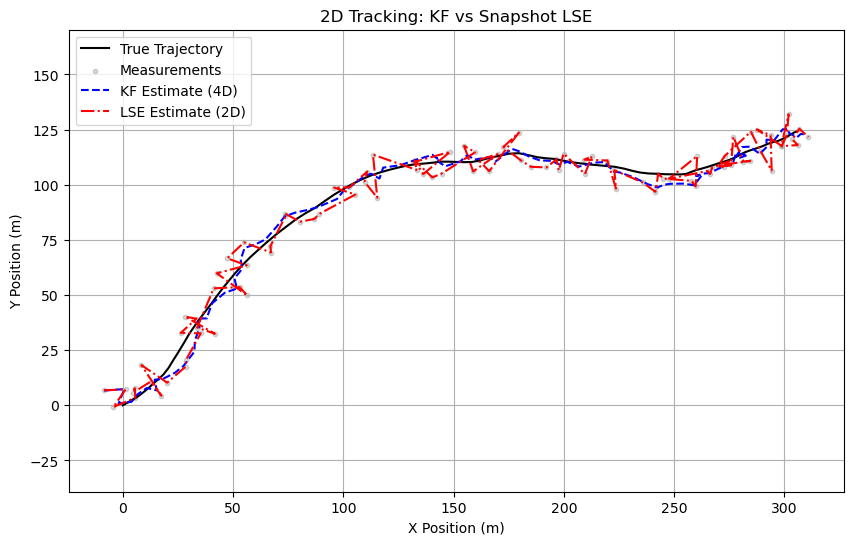

In [101]:
plt.figure(figsize=(10, 6))
plt.plot(x_true[0, :], x_true[2, :], 'k-', label='True Trajectory')
plt.scatter(z_meas[0, :], z_meas[1, :], c='gray', s=10, alpha=0.3, label='Measurements')
plt.plot(x_kf[0, :], x_kf[2, :], 'b--', label='KF Estimate (4D)')
plt.plot(x_lse[0, :], x_lse[2, :], 'r-.', label='LSE Estimate (2D)')
plt.legend()
plt.title('2D Tracking: KF vs Snapshot LSE')
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')
plt.grid(True)
plt.axis('equal')
plt.show()

### Error Analysis (X Position)
Comparision of estimation error.

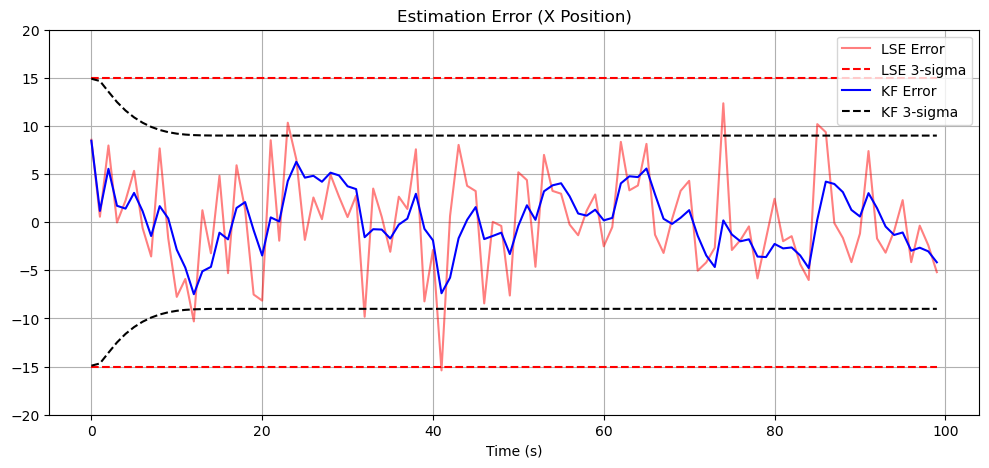

In [102]:
t = np.arange(steps) * dt
err_kf = x_true[0, :] - x_kf[0, :]
err_lse = x_true[0, :] - x_lse[0, :]

std_kf = np.sqrt(P_kf[:, 0, 0])
std_lse = np.sqrt(P_lse[:, 0, 0])

plt.figure(figsize=(12, 5))
plt.plot(t, err_lse, 'r', alpha=0.5, label='LSE Error')
plt.plot(t, 3*std_lse, 'r--', label='LSE 3-sigma')
plt.plot(t, -3*std_lse, 'r--')

plt.plot(t, err_kf, 'b', label='KF Error')
plt.plot(t, 3*std_kf, 'k--', label='KF 3-sigma')
plt.plot(t, -3*std_kf, 'k--')

plt.ylim(-20, 20)
plt.legend()
plt.title('Estimation Error (X Position)')
plt.xlabel('Time (s)')
plt.grid(True)
plt.show()